In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from captum.attr import Saliency, GuidedBackprop, IntegratedGradients
import quantus
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

In [2]:
#Set up
print("--- Chargement du modèle et de l'image ---")

# 1. Charger un modèle pré-entraîné (ResNet50)
model = models.resnet50(pretrained=True)
model.eval() # Mode évaluation

# 2. Charger une image d'exemple (un chien)
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 3. Prétraitement de l'image pour le modèle
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Normalisation ImageNet standard
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0) # Ajouter la dimension du batch

# Trouver la classe prédite
output = model(input_tensor)
prediction_score, pred_label_idx = torch.topk(output, 1)
print(f"Classe prédite : {pred_label_idx.item()} (Chien)")

# Fonction pour afficher les images par la suite
def viz_maps(original, map1, title1, map2, title2):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("Image Originale")
    axes[0].axis('off')
    
    # Affichage carte 1
    axes[1].imshow(map1, cmap='jet', alpha=0.8)
    axes[1].set_title(title1)
    axes[1].axis('off')
    
    # Affichage carte 2
    axes[2].imshow(map2, cmap='jet', alpha=0.8)
    axes[2].set_title(title2)
    axes[2].axis('off')
    plt.show()

--- Chargement du modèle et de l'image ---


/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Classe prédite : 258 (Chien)



--- Génération des explications ---


/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


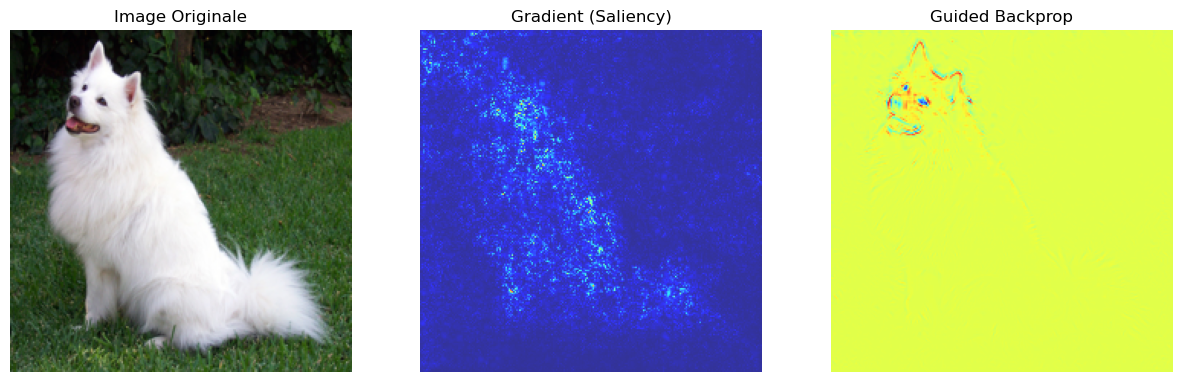

In [3]:
# Génération des méthodes d'interprétabilité
print("\n--- Génération des explications ---")

# On utilise Saliency (Gradient simple) et Guided Backprop
saliency = Saliency(model)
gbp = GuidedBackprop(model)

# Calcul des attributions
attr_saliency = saliency.attribute(input_tensor, target=pred_label_idx)
attr_gbp = gbp.attribute(input_tensor, target=pred_label_idx)

# Traitement pour visualisation (Somme des canaux + valeur absolue)
map_saliency = np.transpose(attr_saliency.squeeze().detach().numpy(), (1, 2, 0)).sum(axis=2)
map_gbp = np.transpose(attr_gbp.squeeze().detach().numpy(), (1, 2, 0)).sum(axis=2)

viz_maps(img.resize((224, 224)), map_saliency, "Gradient (Saliency)", map_gbp, "Guided Backprop")


--- Le Test de cohérence ---


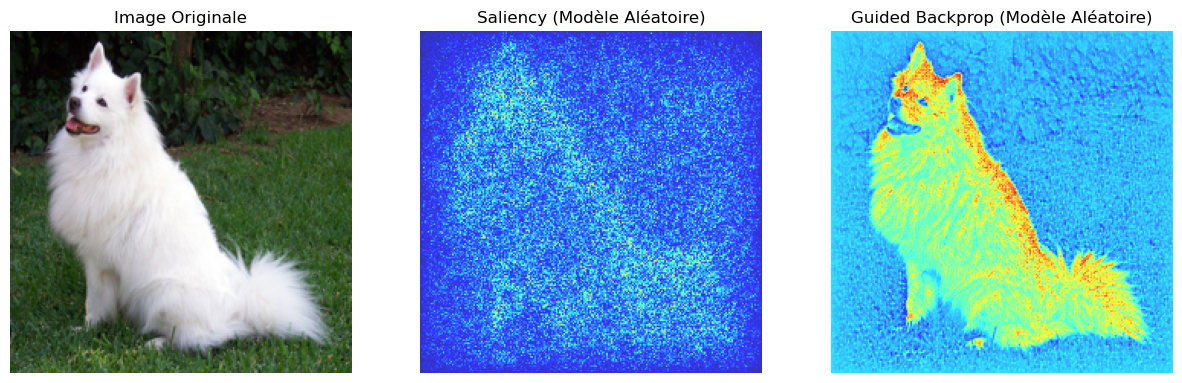

In [5]:
# Test de cohérence
print("\n--- Le Test de cohérence ---")

# On utilise VGG16 car l'effet "Edge Detector" est plus flagrant qu'avec ResNet
from torchvision.models import vgg16

# 1. On charge un VGG16 aléatoire
broken_model = vgg16(pretrained=False)
broken_model.eval()

# 2. On recalcule les explications
saliency_broken = Saliency(broken_model)
gbp_broken = GuidedBackprop(broken_model)

# On utilise la même image input_tensor
attr_sal_broken = saliency_broken.attribute(input_tensor, target=pred_label_idx)
attr_gbp_broken = gbp_broken.attribute(input_tensor, target=pred_label_idx)

map_sal_broken = np.transpose(attr_sal_broken.squeeze().detach().numpy(), (1, 2, 0)).sum(axis=2)
map_gbp_broken = np.transpose(attr_gbp_broken.squeeze().detach().numpy(), (1, 2, 0)).sum(axis=2)

# Affichage
viz_maps(img.resize((224, 224)), map_sal_broken, "Saliency (Modèle Aléatoire)", map_gbp_broken, "Guided Backprop (Modèle Aléatoire)")

La map de gauche représente du bruit gris/noir car le modèle ne sait rien puisqu'il est aléatoire. La méthode d'interprétabilité passe le sanity check.

A l'inverse, la map du Guided Backprop (droite) montre encore les contours du chien alors que le modèle ne sait rien. La méthode d'interprétabilité fonctionne comme un détecteur de contour. Elle ne passe pas le Sanity Check d'Adebayo. C'est ce que nous avions vu en cours !

In [7]:
# L'INSTABILITÉ DES MÉTRIQUES (Tomsett & Quantus)
print("\n--- L'Instabilité de la mesure avec Quantus ---")

# On va mesurer la "Fidélité" (Faithfulness Correlation) de notre Gradient original
# Mais on va changer la couleur de remplacement

# Convertir les données pour Quantus (numpy)
x_batch = input_tensor.detach().numpy()
y_batch = np.array([pred_label_idx.item()])
a_batch = attr_saliency.detach().numpy() # L'explication du Gradient de l'acte 1

# Métrique 1 : remplacement noir (0)
metric_black = quantus.FaithfulnessCorrelation(
    perturb_baseline="black",
    nr_runs=10,  # Nombre d'essais
    return_aggregate=True
)

score_black = metric_black(model=model, x_batch=x_batch, y_batch=y_batch, a_batch=a_batch)

# Métrique 2 : remplacement par la moyenne (Mean)
metric_mean = quantus.FaithfulnessCorrelation(
    perturb_baseline="mean",
    nr_runs=10,
    return_aggregate=True
)

score_mean = metric_mean(model=model, x_batch=x_batch, y_batch=y_batch, a_batch=a_batch)

print(f"Score de Fidélité (Baseline Noire) : {score_black[0]:.4f}")
print(f"Score de Fidélité (Baseline Moyenne): {score_mean[0]:.4f}")



--- L'Instabilité de la mesure avec Quantus ---
Score de Fidélité (Baseline Noire) : 0.2714
Score de Fidélité (Baseline Moyenne): 0.3280


Comme ce que nous avions vu, les scores de fidelité sont très différents en fonction de la méthode de remplacement effectuée. La métrique de fidélité pour cette méthode d'explicabilité de passe pas le Sanity Check de Tomsett.